# Machine Learning Assignment 3 - Advanced Classification and Clustering of Health Conditions

Suppressing all FutureWarnings to enhance code readibility

https://saturncloud.io/blog/how-to-suppress-pandas-future-warning-a-guide-for-data-scientists/#:~:text=Method%201%3A%20Using%20the%20Warnings%20Module&text=In%20this%20example%2C%20we%20import,FutureWarning%20messages%20generated%20by%20Pandas.

In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

### 1. Data Exploration (1 Mark)

- Load the dataset and analyse class distribution and other key characteristics.
- Summarize your findings in a brief data exploration report.

The following link was used to help with exploring and understanding the data:
https://datacarpentry.org/python-ecology-lesson/02-starting-with-data.html

In [2]:
import pandas as pd
from IPython.display import display

In [3]:
df_train = pd.read_csv("C:/Users/Admin/Desktop/MSc/PrinciplesofML/Assignment3/train-3.csv")
df_test = pd.read_csv("C:/Users/Admin/Desktop/MSc/PrinciplesofML/Assignment3/test-4.csv")

df = pd.concat([df_train, df_test], axis=0)

In [4]:
# Inspect the first few rows of the data
df.head()

,COUGH,MUSCLE_ACHES,TIREDNESS,SORE_THROAT,RUNNY_NOSE,STUFFY_NOSE,FEVER,NAUSEA,VOMITING,DIARRHEA,...,DIFFICULTY_BREATHING,LOSS_OF_TASTE,LOSS_OF_SMELL,ITCHY_NOSE,ITCHY_EYES,ITCHY_MOUTH,ITCHY_INNER_EAR,SNEEZING,PINK_EYE,TYPE
0,1,0,1,1,0,1,0,0,0,0,...,0,1,1,1,1,1,0,1,1,ALLERGY
1,1,1,0,0,1,0,0,0,1,1,...,1,1,1,0,0,0,0,1,0,FLU
2,1,1,0,0,1,1,0,0,0,0,...,0,1,1,0,0,0,1,0,1,ALLERGY
3,1,1,0,0,1,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,FLU
4,1,0,1,1,1,1,1,1,1,0,...,1,0,0,0,0,0,0,1,0,FLU


In [5]:
# Check to see what Data Structure we are provided with
type(df)

pandas.core.frame.DataFrame

In [6]:
# Assess what Data Types each column has
datatypes = df.dtypes
display(pd.DataFrame(datatypes).T)

,COUGH,MUSCLE_ACHES,TIREDNESS,SORE_THROAT,RUNNY_NOSE,STUFFY_NOSE,FEVER,NAUSEA,VOMITING,DIARRHEA,...,DIFFICULTY_BREATHING,LOSS_OF_TASTE,LOSS_OF_SMELL,ITCHY_NOSE,ITCHY_EYES,ITCHY_MOUTH,ITCHY_INNER_EAR,SNEEZING,PINK_EYE,TYPE
0,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,...,int64,int64,int64,int64,int64,int64,int64,int64,int64,object


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 44453 entries, 0 to 4445
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   COUGH                 44453 non-null  int64 
 1   MUSCLE_ACHES          44453 non-null  int64 
 2   TIREDNESS             44453 non-null  int64 
 3   SORE_THROAT           44453 non-null  int64 
 4   RUNNY_NOSE            44453 non-null  int64 
 5   STUFFY_NOSE           44453 non-null  int64 
 6   FEVER                 44453 non-null  int64 
 7   NAUSEA                44453 non-null  int64 
 8   VOMITING              44453 non-null  int64 
 9   DIARRHEA              44453 non-null  int64 
 10  SHORTNESS_OF_BREATH   44453 non-null  int64 
 11  DIFFICULTY_BREATHING  44453 non-null  int64 
 12  LOSS_OF_TASTE         44453 non-null  int64 
 13  LOSS_OF_SMELL         44453 non-null  int64 
 14  ITCHY_NOSE            44453 non-null  int64 
 15  ITCHY_EYES            44453 non-null  int6

In [8]:
column_names = df.columns.tolist()

In [9]:
# Checking for missing values in each variable
df.isnull().sum()

COUGH                   0
MUSCLE_ACHES            0
TIREDNESS               0
SORE_THROAT             0
RUNNY_NOSE              0
STUFFY_NOSE             0
FEVER                   0
NAUSEA                  0
VOMITING                0
DIARRHEA                0
SHORTNESS_OF_BREATH     0
DIFFICULTY_BREATHING    0
LOSS_OF_TASTE           0
LOSS_OF_SMELL           0
ITCHY_NOSE              0
ITCHY_EYES              0
ITCHY_MOUTH             0
ITCHY_INNER_EAR         0
SNEEZING                0
PINK_EYE                0
TYPE                    0
dtype: int64

The display function was used to more easily view the distribution of each variable. The following link helped in understanding how to use the display function:

https://www.geeksforgeeks.org/display-the-pandas-dataframe-in-table-style/

In [10]:
# create a function to apply value_counts function to get distrubtion for all variables specified in a given list for the given dataframe
def value_counts_variables(dataframe, variable_list):
    for v in variable_list:
        if v in dataframe.columns:
            description = dataframe[v].value_counts(normalize=True)*100
            description = description.round(1).astype(str) + '%'
            display(description.to_frame().T)            
        else:
            print(f"Warning: {v} is not a column in the DataFrame")

In [11]:
# apply value_counts to all categorical variables in df
value_counts_variables(df, column_names)

COUGH,1,0
proportion,52.1%,47.9%


MUSCLE_ACHES,1,0
proportion,52.0%,48.0%


TIREDNESS,1,0
proportion,52.0%,48.0%


SORE_THROAT,1,0
proportion,51.9%,48.1%


RUNNY_NOSE,0,1
proportion,50.4%,49.6%


...

ITCHY_MOUTH,0,1
proportion,81.6%,18.4%


ITCHY_INNER_EAR,0,1
proportion,81.6%,18.4%


SNEEZING,1,0
proportion,51.9%,48.1%


PINK_EYE,0,1
proportion,81.6%,18.4%


TYPE,FLU,ALLERGY,COVID,COLD
proportion,56.2%,36.9%,4.6%,2.3%


Based on the above we see that large class imbalance exists with:

- TYPE: COVID and COLD relatively low prevalance
- PINK EYE
- ITCHY MOUTH
- ITCHY EYES
- ITCHY NOSE

Based on the above we see that moderate class imbalance exists with:

- FEVER
- NAUSEA
- VOMITING
- DIARRHEA
- SHORTNESS OF BREATH
- DIFFICULTY BREATHING

As can be seen above, it is important that class imbalances are addressed as part of the model fitting process. This can include the following techniques:

- Resampling (Oversampling or Undersampling)
- Selecting appropriate performance metrics (e.g., Accuracy can be misleading) such as Confusion matrix, Precision, Recall, F1 score, AUC
- Selecting models which can handle class imbalances well e.g., Decision Trees, Random Forests, ensemble methods
  
https://www.analyticsvidhya.com/articles/class-imbalance-in-machine-learning/#:~:text=Non%2Dfraudulent).-,Resampling%20Techniques%20to%20Solve%20Class%20Imbalance,class%20(over%2Dsampling).

### 2. Classification (3.5 Marks)

**Goal**: 

Build a classifier to predict the TYPE label in the test set using advanced machine learning or ensemble methods.

**Requirements**:
- Experiment with at least two algorithms (e.g., decision tree, kNN) or using an ensemble approach. Remember you can use other variants of the algorithms we studied in the module. Or use other traditional algorithms like SVM as well.
- Ensure that your model is a well generalised model. To do that justify what steps have you taken e.g. do you need cross validation.
- Report accuracy, precision, recall, and F1-score for both validation and test sets.

**Challenge**:

Compete for top accuracy. The groups will be ranked at the end of the assignment based on their accuracy and how they presented the work. A group list with their respective marks will be shared with all. (If a group do not want to be ranked in the list that will be shared with all, they can let me know and I will remove them from the list). The link to the form is board is here: https://forms.office.com/e/K2YQLNwhrs

**Dealing with Class Imbalance**:

- Start with the overall train and test set provided to us but combined into one
- Separate the features and target variable
- Then use SMOTE to balance the classes

In [62]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

In [25]:
# Separate features and target variable
X = df.drop('TYPE', axis=1)  
y = df['TYPE']

In [26]:
# Apply SMOTE to balance the classes
smote = SMOTE(random_state=123)
X_resampled, y_resampled = smote.fit_resample(X, y)

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=123)

**(1) Decision Tree**

Brief Explanation of Model:

The decision tree classifier organizes data like a binary search tree. For example, with features like height and weight to decide pilot eligibility, it splits data at the root (e.g. fever), with branches for "no" or further checks (e.g. nausea). Basing outcomes are on threshold comparisons.no draw.


What we did:

We tested the algorithm for different types of fitting and the best one was using a mix of both under/overfitting using Synthetic Minority Oversampling Technique (SMOTE & SMOTEENN) to address the problem of class imbalance, along with testing for various hyperparameters through grid search (max depth, min samples split, min samples leaf) iteratively changing the values that grid search would use to get a more detailed insight  on what worked the best for this data set. Additionally, one of the benefits of using a simple algorithm like Decision tree for any dataset is that it is really easy to visualize which may give you insights on which algorithms to use with it.

Summary:

To summarize the Accuracy is 92.47% the confusion matrix showed as indicated in the Tree that there are some Types that worked really well like Flu and Allergy at the cost of the other 2 which is what can be expected from a not so balanced dataset.

It is known that other algorithms (e.g., ensemble methods) may be better suited to modeling imbalanced datasets. We will therefore investigate other algorithms before comparing what the best performing model is.

In [1]:
import pandas as pd
from imblearn.under_sampling import RandomUnderSampler
from matplotlib import pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN

In [2]:
# Function that separates the data into features (X) and target (y)
def split_into_x_and_y(data, target_column):
    # Converting categorical target values into numeric representations
    results_y = data[target_column].replace("COVID", 0).replace("ALLERGY", 1).replace("FLU", 2).replace("COLD", 3)

    # Removing the target column from the feature set
    data_x = data.drop(columns=[target_column])
    return data_x, results_y


# Load training and testing data
train_data = pd.read_csv('train-3.csv')
test_data = pd.read_csv('test-4.csv')
# print("Unique values in train TYPE column:", train_data["TYPE"].unique())

# Extract features and targets from training data
# train_x, train_y = split_into_x_and_y(train_data, "TYPE")

# Oversample minority classes
X, Y = split_into_x_and_y(train_data, "TYPE")
# smote = SMOTE(random_state=2)
# train_x, train_y = smote.fit_resample(X, Y)

# undersample
# undersampler = RandomUnderSampler(random_state=2)
# train_x, train_y = undersampler.fit_resample(X, Y)

# both over and under sampling
smote_enn = SMOTEENN(random_state=2)
train_x, train_y = smote_enn.fit_resample(X, Y)

# Check new class distribution
print(train_y.value_counts())


TYPE
1    19298
3    18908
0    17357
2    14223
Name: count, dtype: int64


In [3]:
# Function that separates the data into features (X) and target (y)
def split_into_x_and_y(data, target_column):
    # Converting categorical target values into numeric representations
    results_y = data[target_column].replace("COVID", 0).replace("ALLERGY", 1).replace("FLU", 2).replace("COLD", 3)

    # Removing the target column from the feature set
    data_x = data.drop(columns=[target_column])
    return data_x, results_y


# Load training and testing data
train_data = pd.read_csv('train-3.csv')
test_data = pd.read_csv('test-4.csv')
# print("Unique values in train TYPE column:", train_data["TYPE"].unique())

# Extract features and targets from training data
# train_x, train_y = split_into_x_and_y(train_data, "TYPE")

# Oversample minority classes
X, Y = split_into_x_and_y(train_data, "TYPE")
# smote = SMOTE(random_state=2)
# train_x, train_y = smote.fit_resample(X, Y)

# undersample
# undersampler = RandomUnderSampler(random_state=2)
# train_x, train_y = undersampler.fit_resample(X, Y)

# both over and under sampling
smote_enn = SMOTEENN(random_state=2)
train_x, train_y = smote_enn.fit_resample(X, Y)

# Check new class distribution
print(train_y.value_counts())


TYPE
1    19298
3    18908
0    17357
2    14223
Name: count, dtype: int64


In [4]:
# Extract features and targets from testing data
test_x, test_y = split_into_x_and_y(test_data, "TYPE")

# Define the decision tree classifier
classifier = DecisionTreeClassifier(random_state=2)

# Define the grid of hyperparameters
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [18, 19, 20, 21, 22],
    'min_samples_split': [2, 3, 5],
    'min_samples_leaf': [1, 2],
}

# Perform grid search with 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=classifier,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
)

# Fit the grid search on the training data
grid_search.fit(train_x, train_y)

# Print the best hyperparameters and best score
print(f"Best Hyperparameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.2f}")

Best Hyperparameters: {'criterion': 'gini', 'max_depth': 19, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Cross-Validation Accuracy: 1.00


In [5]:
# Use the best estimator to make predictions on the test data
best_classifier = grid_search.best_estimator_
predictions = best_classifier.predict(test_x)

# Calculate the accuracy on the test data
accuracy = accuracy_score(test_y, predictions)
print(f"Test Accuracy with Best Hyperparameters: {accuracy * 100:.2f}%")

Test Accuracy with Best Hyperparameters: 92.47%


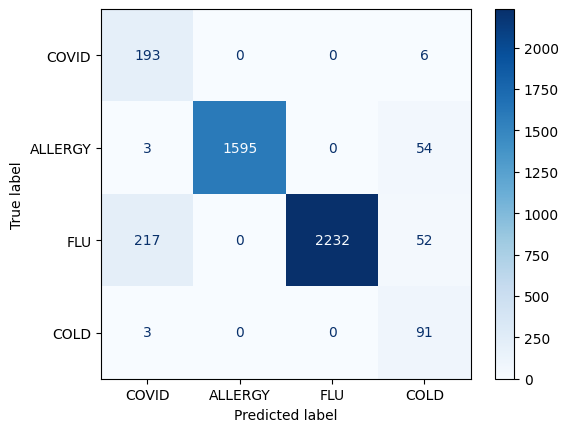

In [6]:
cm = confusion_matrix(test_y, predictions)
target_names = ["COVID", "ALLERGY", "FLU", "COLD"]
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)

disp.plot(cmap=plt.cm.Blues)
plt.show()

In [7]:
print("Confusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(test_y, predictions, target_names=target_names))

Confusion Matrix:
[[ 193    0    0    6]
 [   3 1595    0   54]
 [ 217    0 2232   52]
 [   3    0    0   91]]

Classification Report:
              precision    recall  f1-score   support

       COVID       0.46      0.97      0.63       199
     ALLERGY       1.00      0.97      0.98      1652
         FLU       1.00      0.89      0.94      2501
        COLD       0.45      0.97      0.61        94

    accuracy                           0.92      4446
   macro avg       0.73      0.95      0.79      4446
weighted avg       0.96      0.92      0.94      4446



**(2) Ensemble method: Random Forest**

https://www.geeksforgeeks.org/random-forest-classifier-using-scikit-learn/

Brief Explanation of Model:

Random Forest is also a supervised learning method and can be used for classification and regression problems. Random Forests 
work well with large and complex datasets, and high-dimensional feature spaces.  It is an ensemble algorithm where a set of 
decision trees are created from a randomly selected subset of the training set. For classification problems, it collects the votes from 
all the decision trees and the final prediction is based on the majority vote
.  
This approach, known as bagging (Bootstrap Aggregation), prevents dominance of any single feature and reduces overfitting 
resulting in a more robust model. When creating the decision trees, the best feature at each node point is selected based on a given 
crit.d.)  (gini, entropy, log_loss). Gini is used for the purpose of this exercise since it is computationally simpler 
and faster to calculate due to its linear characteristics. 

What we did:

In the data pre-processing step we used Synthetic Minority Oversampling Technique (SMOTE) to address the problem of class imbalance. SMOTE is specifically designed to tackle imbalanced datasets by generating synthetic samples for the minority class.

Grid search was then used to select the best hyperparameters for max depth and number of estimators. A visual displaying the Accuracy for various combinations of these hyperparamaters is shown below.

When the hyperparamaters were selected, the model was evaluated, calculating metrics such as Accuracy, Precision, Recall, F1 and Area under the Curve (AUC). A confusion matrix was also created.

Summary:

Accuracy, Precision, Recall and F1 was 0.96. AUC was 0.99.

As expected, the Random Forest performed stronger than KNN.

In [12]:
from sklearn.ensemble import RandomForestClassifier

In [53]:
random_state=123

from sklearn.model_selection import GridSearchCV
param_grid = {'n_estimators': list(range(1, 150)),
              'max_depth': [2, 4, 8, 12, 16, 20, None]}
grid = GridSearchCV(RandomForestClassifier(random_state=random_state,criterion='gini'), 
                    param_grid, cv=5) 
grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=123),
             param_grid={'max_depth': [2, 4, 8, 12, 16, 20, None],
                         'n_estimators': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
                                          13, 14, 15, 16, 17, 18, 19, 20, 21,
                                          22, 23, 24, 25, 26, 27, 28, 29, 30, ...]})

In [54]:
grid.best_params_

{'max_depth': 12, 'n_estimators': 28}

In [55]:
output = grid.cv_results_

df = pd.DataFrame({
    'max_depth': [params['max_depth'] for params in output['params']],
    'n_estimators': [params['n_estimators'] for params in output['params']],
    'accuracy': output['mean_test_score']
})

In [56]:
print(df)

      max_depth  n_estimators  accuracy
0           2.0             1  0.506975
1           2.0             2  0.620463
2           2.0             3  0.747500
3           2.0             4  0.814112
4           2.0             5  0.794625
...         ...           ...       ...
1038        NaN           145  0.955363
1039        NaN           146  0.955400
1040        NaN           147  0.955400
1041        NaN           148  0.955412
1042        NaN           149  0.955412

[1043 rows x 3 columns]


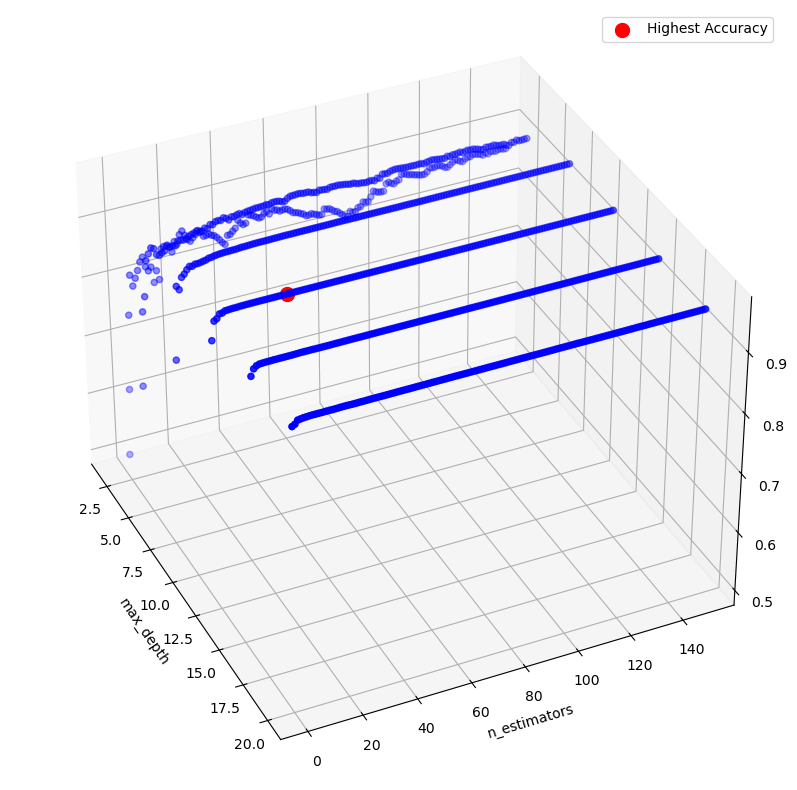

In [57]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')
ax.set_xlabel('max_depth')
ax.set_ylabel('n_estimators')
ax.set_zlabel('accuracy');

# plot the data (small blue circles) 
ax.scatter(df['max_depth'], df['n_estimators'], df['accuracy'],color='b') 

# Find the index of the maximum accuracy
best_param = df['accuracy'].idxmax()

# Highlight the point with the highest accuracy 
ax.scatter(df.loc[best_param, 'max_depth'], 
           df.loc[best_param, 'n_estimators'], 
           df.loc[best_param, 'accuracy'], 
           color='r', s=100, label='Highest Accuracy')
# set the viewing angle
ax.view_init(elev=35., azim=-25);
ax.legend()
plt.show()

In [59]:
clf = RandomForestClassifier(n_estimators=28, max_depth=12, random_state=random_state,criterion='gini')
clf.fit(X_train, y_train)

RandomForestClassifier(max_depth=12, n_estimators=28, random_state=123)

Accuracy: 0.96
Precision: 0.96
Recall: 0.96
F1 Score: 0.96
ROC-AUC (One-vs-Rest): 0.9891440290894102
ROC-AUC (One-vs-One): 0.9891854223048733


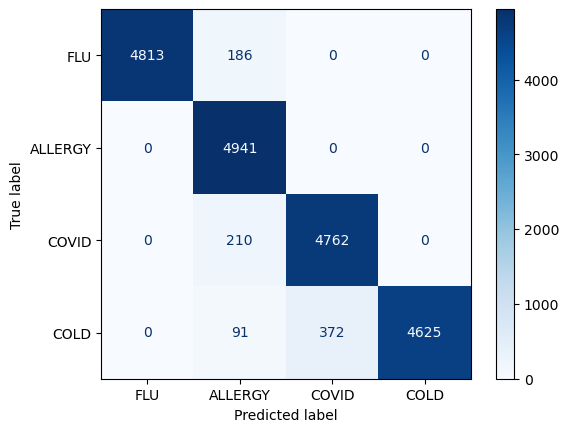

In [63]:
# Random Forest
y_pred = clf.predict(X_test)
y_pred_proba = clf.predict_proba(X_test) # required for ROC-AUC

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

roc_auc_ovr = roc_auc_score(y_test, y_pred_proba, multi_class='ovr')
roc_auc_ovo = roc_auc_score(y_test, y_pred_proba, multi_class='ovo')

print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')
print(f'ROC-AUC (One-vs-Rest): {roc_auc_ovr}')
print(f'ROC-AUC (One-vs-One): {roc_auc_ovo}')

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [64]:
y_pred = clf.predict(X_test)

# Print classification report and confusion matrix
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

     ALLERGY       1.00      0.96      0.98      4999
        COLD       0.91      1.00      0.95      4941
       COVID       0.93      0.96      0.94      4972
         FLU       1.00      0.91      0.95      5088

    accuracy                           0.96     20000
   macro avg       0.96      0.96      0.96     20000
weighted avg       0.96      0.96      0.96     20000

[[4813  186    0    0]
 [   0 4941    0    0]
 [   0  210 4762    0]
 [   0   91  372 4625]]


### 3. Clustering (3.5 Marks)

**Goal**: 

Apply clustering to explore inherent patterns and analyze how clusters align with the known classes.

**Requirements**:
- Use at least two clustering algorithms, such as K-Means, Hierarchical clustering, DBSCAN, Agglomerative Clustering, or Gaussian Mixture Models.
- Evaluate clusters using metrics like silhouette score or adjusted Rand index, and visualize the results.
- Compare clustering output with true labels and discuss alignment. Furthermore, plot it nicely using any off the shelf libraries to highlight the clusters.

**Some Preparation**:

In [17]:
from hdbscan import HDBSCAN

In [20]:
pip install umap-learn


   ---------------------------------------- 0.0/88.8 kB ? eta -:--:--
   ---- ----------------------------------- 10.2/88.8 kB ? eta -:--:--
   ------------------------------------ --- 81.9/88.8 kB 1.2 MB/s eta 0:00:01
   ---------------------------------------- 88.8/88.8 kB 1.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/56.9 kB ? eta -:--:--
   ------------------------------------ --- 51.2/56.9 kB ? eta -:--:--
   ---------------------------------------- 56.9/56.9 kB 2.9 MB/s eta 0:00:00


In [21]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight
from sklearn.cluster import DBSCAN, KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score, silhouette_score
# !pip install --upgrade scikit-learn imbalanced-learn
import umap.umap_ as umap

In [22]:
test_data = pd.read_csv("test-4.csv")
data = pd.read_csv("train-3.csv")

In [23]:
# encode target labels with numerical classes from 0 to n-1 classes
enco = LabelEncoder()
data["TYPE"] = enco.fit_transform(data["TYPE"])
test_data["TYPE"] = enco.fit_transform(test_data["TYPE"])

In [24]:
# split data into features and targets
X_train = data.drop(["TYPE"], axis=1)
y_train = data["TYPE"]
X_test = test_data.drop(["TYPE"], axis=1)
y_test = test_data["TYPE"]

In [25]:
# sample weights computed given that the data sets are heavility unbalanced
sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)

In [26]:
# umap dimensionality reduction using hamming distance (because we have binary data)
umap_model = umap.UMAP(metric="hamming", random_state=0)
X_train_reduced = umap_model.fit_transform(X_train, y_train, sample_weight=sample_weights)
X_test_reduced = umap_model.transform(X_test)

C:\Users\Admin\anaconda4\Lib\site-packages\umap\umap_.py:1887: UserWarning: gradient function is not yet implemented for hamming distance metric; inverse_transform will be unavailable
  warn(
C:\Users\Admin\anaconda4\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [27]:
# check the shape of the train and test data
X_train_reduced.shape, X_test_reduced.shape

((40007, 2), (4446, 2))

**(1) DBSCAN**

In [28]:
# dbscan with fit_predict on both X_train and X_test
clusterer_dbscan = DBSCAN(eps=2.5)
clusters_dbscan_train = clusterer_dbscan.fit_predict(X_train_reduced)
clusters_dbscan_test = clusterer_dbscan.fit_predict(X_test_reduced)

In [29]:
# show difference between clusters predictions and true output
# note -1 refers to misclassified data
np.unique(clusters_dbscan_train, return_counts=True), np.unique(y_train, return_counts=True)

((array([-1,  0,  1,  2,  3], dtype=int64),
  array([    2, 14732, 22496,  1849,   928], dtype=int64)),
 (array([0, 1, 2, 3]), array([14729,   930,  1849, 22499], dtype=int64)))

In [30]:
np.unique(clusters_dbscan_test, return_counts=True), np.unique(y_test, return_counts=True)

((array([0, 1, 2, 3], dtype=int64),
  array([2488,  207, 1641,  110], dtype=int64)),
 (array([0, 1, 2, 3]), array([1652,   94,  199, 2501], dtype=int64)))

Text(0.5, 1.0, 'DBSCAN Prediceted Clusters- Test')

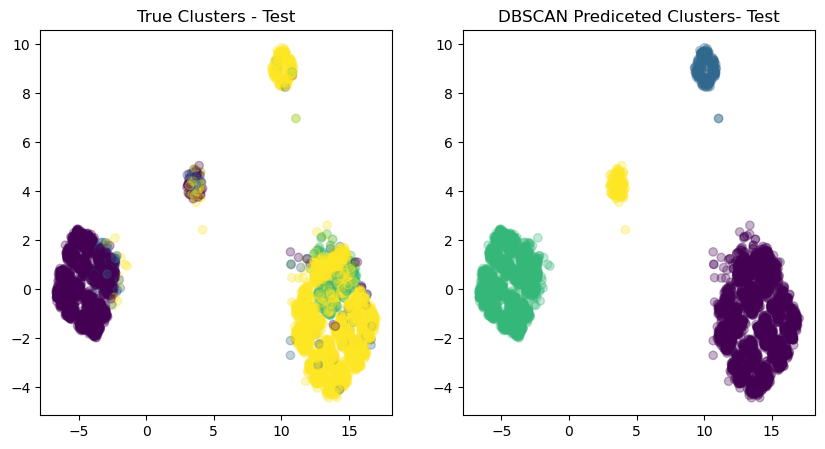

In [31]:
fig, axs = plt.subplots(1, 2, figsize=(10,5))
axs[0].scatter(X_test_reduced[:, 0], X_test_reduced[:, 1], c=y_test, alpha=0.3)
axs[0].set_title("True Clusters - Test")
axs[1].scatter(X_test_reduced[:, 0], X_test_reduced[:, 1], c=clusters_dbscan_test, alpha=0.3)
axs[1].set_title("DBSCAN Prediceted Clusters- Test")

In [32]:
# silhouette score
silhouette_dbscan = silhouette_score(X_test_reduced, clusters_dbscan_test)
silhouette_dbscan

0.76717246

In [33]:
# ARS score
ars_dbscan = adjusted_rand_score(y_test, clusters_dbscan_test)
ars_dbscan

0.7362453624116904

**(2) GMM**

In [35]:
# gaussian mixtures with 4 clusters
clusterer_gmm = GaussianMixture(n_components=4)
clusterer_gmm_train = clusterer_gmm.fit(X_train_reduced)
clusters_gmm_train = clusterer_gmm_train.predict(X_train_reduced)
clusters_gmm_test = clusterer_gmm_train.predict(X_test_reduced)

In [36]:
np.unique(clusters_gmm_train, return_counts=True), np.unique(y_train, return_counts=True)

((array([0, 1, 2, 3], dtype=int64),
  array([14734, 12025,  2777, 10471], dtype=int64)),
 (array([0, 1, 2, 3]), array([14729,   930,  1849, 22499], dtype=int64)))

In [37]:
np.unique(clusters_gmm_test, return_counts=True), np.unique(y_test, return_counts=True)

((array([0, 1, 2, 3], dtype=int64),
  array([1641, 1302,  317, 1186], dtype=int64)),
 (array([0, 1, 2, 3]), array([1652,   94,  199, 2501], dtype=int64)))

Text(0.5, 1.0, 'GMM Prediceted Clusters- Test')

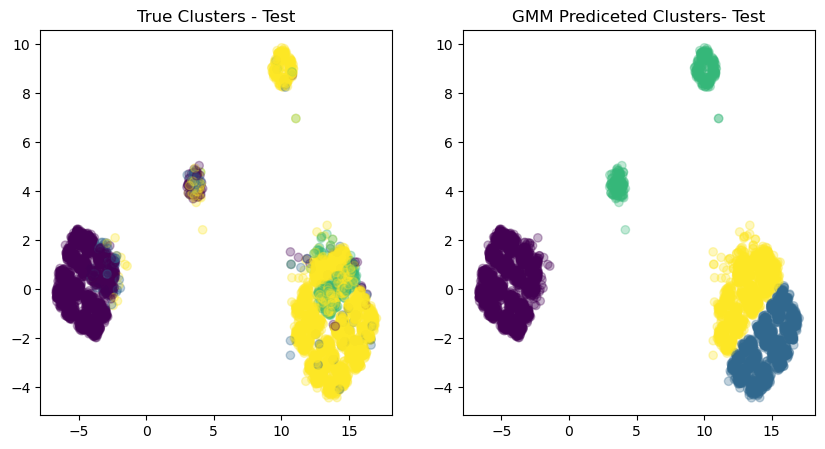

In [38]:
fig, axs = plt.subplots(1, 2, figsize=(10,5))
axs[0].scatter(X_test_reduced[:, 0], X_test_reduced[:, 1], c=y_test, alpha=0.3)
axs[0].set_title("True Clusters - Test")
axs[1].scatter(X_test_reduced[:, 0], X_test_reduced[:, 1], c=clusters_gmm_test, alpha=0.3)
axs[1].set_title("GMM Prediceted Clusters- Test")

In [39]:
# silhouette score
silhouette_gmm = silhouette_score(X_test_reduced, clusters_gmm_test)
silhouette_gmm

0.569635

In [40]:
# ARS score
ars_gmm = adjusted_rand_score(y_test, clusters_gmm_test)
ars_gmm

0.5297965341775638